GD theta0 (scaled): 1.663836242035198e-16
GD theta1 (scaled): 0.453665476070736
sklearn θ0 (raw): 2.7722832471361034 θ1 (raw): 2.835284335220283e-05
sk Pred @ 5,296  : 2.9224399055293695
sk Pred @ 82,715 : 5.11748868501356


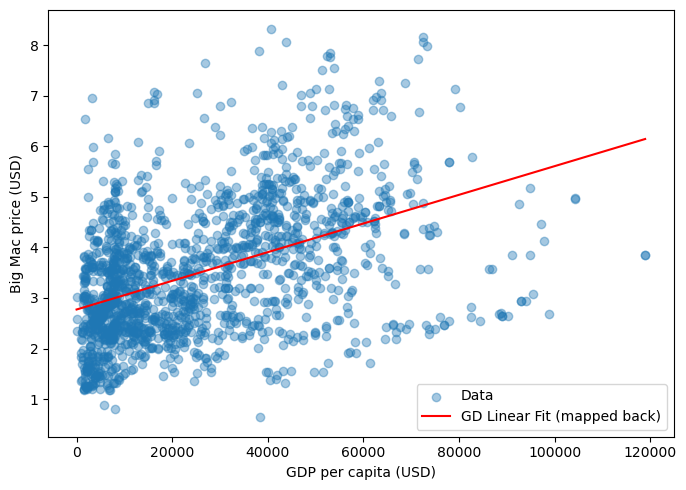

GD Pred @ 5,296  : 2.9224399055293735
GD Pred @ 82,715 : 5.1174886850135515


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# --- Load data ---
df = pd.read_csv("../data/bigmac.csv")
df = df.dropna(subset=["dollar_price", "GDP_bigmac"])

# Ensure float64
x_raw = df["GDP_bigmac"].to_numpy(dtype=np.float64)  # shape (n,)
y_raw = df["dollar_price"].to_numpy(dtype=np.float64)

# --- Standardize (mean=0, std=1) for *GD only* ---
x_mu, x_sigma = x_raw.mean(), x_raw.std() + 1e-8
y_mu, y_sigma = y_raw.mean(), y_raw.std() + 1e-8

x = (x_raw - x_mu) / x_sigma           # standardized features for GD
y = (y_raw - y_mu) / y_sigma           # standardized target for GD

# --- Import your GD class ---
import sys
sys.path.append("../src")
from gradient_descent import LinearRegressionGD1D

# Train GD on standardized data
model = LinearRegressionGD1D(alpha=1e-2, n_iters=5000)
model.fit(x, y)

print("GD theta0 (scaled):", model.theta0)
print("GD theta1 (scaled):", model.theta1)

# --- Fit sklearn on RAW data (no scaling) ---
# 2-D feature matrix required
X_raw_2d = x_raw.reshape(-1, 1)
sk = LinearRegression().fit(X_raw_2d, y_raw)

print("sklearn θ0 (raw):", sk.intercept_, "θ1 (raw):", sk.coef_[0])

# --- Predict with sklearn on RAW GDP values (no manual scaling needed) ---
print("sk Pred @ 5,296  :", float(sk.predict(np.array([[5296]]))[0]))
print("sk Pred @ 82,715 :", float(sk.predict(np.array([[82715]]))[0]))

# --- Plot in original scale using GD ---
plt.figure(figsize=(7, 5))
plt.scatter(x_raw, y_raw, alpha=0.4, label="Data")

x_line_raw = np.linspace(x_raw.min(), x_raw.max(), 200)

# Transform x to scaled space for GD prediction
x_line_scaled = (x_line_raw - x_mu) / x_sigma
y_line_scaled = model.predict(x_line_scaled)

# Invert y scaling back to original units
y_line = y_line_scaled * y_sigma + y_mu

plt.plot(x_line_raw, y_line, color="red", label="GD Linear Fit (mapped back)")
plt.xlabel("GDP per capita (USD)")
plt.ylabel("Big Mac price (USD)")
plt.legend()
plt.tight_layout()
plt.show()


# --- Make predictions with GD at raw GDP values ---
# Convert raw -> scaled -> predict -> inverse scale
def gd_predict_on_raw(gdp_val_raw: float) -> float:
    x_scaled = (np.array([gdp_val_raw]) - x_mu) / x_sigma
    y_scaled = model.predict(x_scaled)[0]
    return float(y_scaled * y_sigma + y_mu)

print("GD Pred @ 5,296  :", gd_predict_on_raw(5296))
print("GD Pred @ 82,715 :", gd_predict_on_raw(82715))